In [1]:
"https://github.com/danielbyiringiro/intro_to_ai_labs/blob/main/Lab_1_Part_A.ipynb"

'https://github.com/danielbyiringiro/intro_to_ai_labs/blob/main/Lab_1_Part_A.ipynb'

In [2]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [4]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [5]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [6]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state==self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_action=[]
        for action,(x,y)  in MOVES.items():
            neighbour=(state[0]+x,state[1]+y)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_action.append(action) 
        return legal_action    
        raise NotImplementedError("Complete GridProblem.actions")
        
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row,col=state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [7]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [8]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [9]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

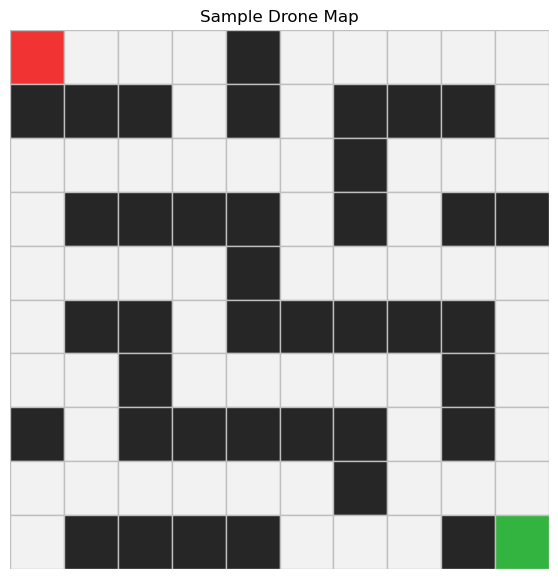

In [10]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [11]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s=node.state
        for action in problem.actions(s):
            s_prime=problem.result(s,action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [12]:

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        max_frontier_size = 1
        nodes_expanded=0
        # 1. Create the initial node from problem.initial_state().
        node=Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if(problem.is_goal(node.state)):
            return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=node,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=1,
                        reached_count=1
                ) 
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached={problem.initial_state()}
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        while len(frontier)>0:
            node = frontier.popleft()
            nodes_expanded+=1
            for child in self.expand(problem, node):
                s=child.state
                if problem.is_goal(s):
                    # Check frontier size one last time before returning
                    max_frontier_size = max(max_frontier_size, len(frontier))
                    return SearchResult(
                            algorithm=algorithm,
                            status="success",
                            solution=child,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size=max_frontier_size,
                            reached_count=1
                        )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size=max(max_frontier_size, len(frontier))
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        
        return  SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )        

In [13]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # Track search metrics
        nodes_expanded = 0
        max_frontier_size = 1
        
        # 1. Create the initial node.
        node = Node(problem.initial_state())
        
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=1,
                reached_count=1
            )
            
        # 3. Use a Python list as the stack frontier.
        frontier = [node]
        
        # 4. Use a reached set.
        reached = {node.state}
        
        # 5. While frontier is not empty:
        while len(frontier) > 0:
            # a. pop from the end of the list.
            node = frontier.pop()
            
            # b. increment nodes_expanded.
            nodes_expanded += 1
            
            # c. expand the node (reversing children to match MOVES order).
            children = list(self.expand(problem, node))
            children.reverse() 
            
            for child in children:
                s = child.state
                
                # Check for goal
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                    
                # d. add unreached children to the stack.
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            
            # e. update max_frontier_size.
            # FIX: Moved inside the while loop to track max size correctly
            max_frontier_size = max(max_frontier_size, len(frontier))
            
        # Return failure if the frontier becomes empty without finding the goal
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.



In [14]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state): 
            return (node, "success")        
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth>=limit:
            return (None, "cutoff")
        # 3. Otherwise:
        else:           
        #   a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"]+=1
        #   b. set cutoff_occurred = False.
            cutoff_occurred = False         
        #   c. for each child in expand(problem, node):
            for child in self.expand(problem, node):
        #       i. skip the child if child.state already appears on the current path.
                is_duplicate = False
                current = node
                while current is not None:
                    if child.state == current.state:
                        is_duplicate = True
                        break
                    current = current.parent
                if is_duplicate:
                    continue
        #       ii. update max_stack_size.
                metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)
        #       iii. recursively call _recursive_dls on the child.
                result_node,result=self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size+1
                )                
        #       iv. if result is "success", return success immediately.
                if result=="success":
                    return(result_node,"success")
                
        #       v. if result is "cutoff", set cutoff_occurred = True.
                if result=="cutoff":
                    cutoff_occurred = True
        #   d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
            if cutoff_occurred:
                return (None, "cutoff")
        #             else return (None, "failure")
            else:
                return (None, "failure")


In [19]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log=[]
        # 2. Accumulate total nodes expanded across all DLS iterations.
        total_nodes_expanded = 0
        # 3. Track the maximum stack size seen in any DLS run.
        overall_max_frontier_size = 1
        dls = DepthLimitedSearch()
        for limit in range(max_depth+1):
            result = dls.search(problem, limit=limit)
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_frontier_size": result.max_frontier_size,
            })
            total_nodes_expanded += result.nodes_expanded
            overall_max_frontier_size = max(overall_max_frontier_size, result.max_frontier_size)
        # 4. If a DLS run returns success, return a SearchResult for IDS.
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_frontier_size,
                    reached_count=0,
                    iterations=iteration_log
                )
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_frontier_size,
                    reached_count=0,
                    iterations=iteration_log
                )
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=overall_max_frontier_size,
            reached_count=0,
            iterations=iteration_log
        )
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
 

In [20]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,1
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,10,0
3,IDS,success,NaN,18.0,18.0,356,18,0


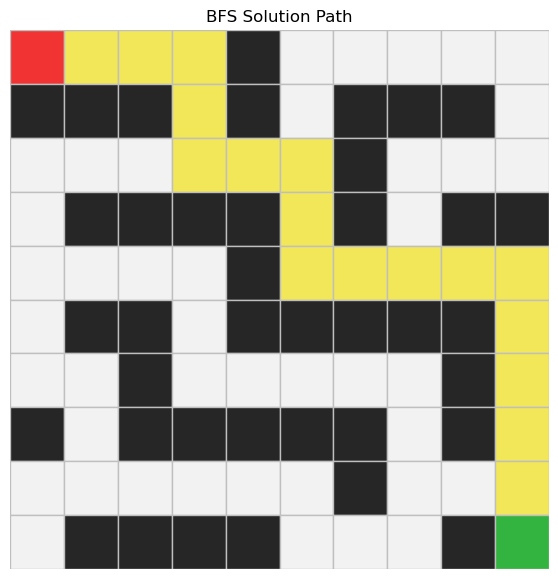

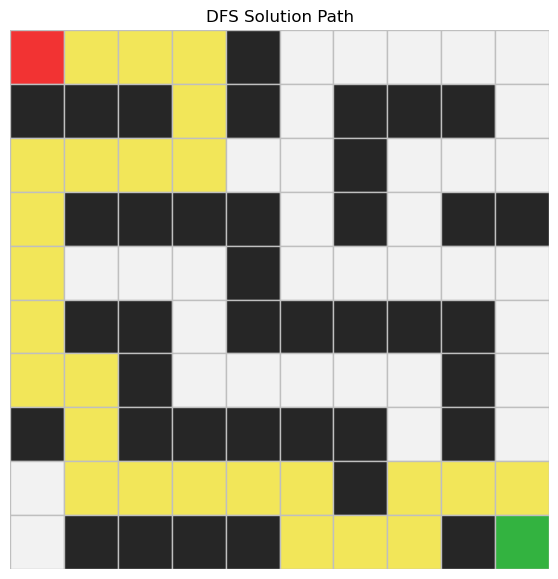

In [21]:

# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [22]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
    
]

custom_start_1 = (0,0)
custom_goal_1 =(14,14)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,78,2,78
1,DFS,failure,NaN,None,None,78,2,78
2,DLS,cutoff,20.0,None,None,39,20,0
3,IDS,cutoff,NaN,None,None,1600,40,0


In [24]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]

custom_start_2 = (0,0)
custom_goal_2 = (14,14)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,112.0,112.0,112,1,1
1,DFS,success,NaN,112.0,112.0,112,1,112
2,DLS,cutoff,20.0,NaN,NaN,20,20,0
3,IDS,cutoff,NaN,NaN,NaN,820,40,0


In [ ]:
"""
15.1 Problem Formulation
1. What is a state in this lab?
    A state in this lab is the specific location of the drone within the environment at
    any point in time. It is represented as a tuple of (row, col) to specify the 
    coordinates of the drone, which is a single cell on the grid map.
    
2. What is an action?
    An action is the available moves the drone can execute from its current cell.
    The movement directions are "UP", "DOWN", "LEFT", and "RIGHT".

3. What does the result function do?
     The return function returns the next state after applying the action to the current
     state. Its parameters are the state and action. It computes the outcome state that 
     occurs when the drone takes a specific action from a given state.

4. Why is it useful to separate the problem definition from the search algorithm?
    It allows the code to be reused for entirely different problems. The same BFS, DFS, DLS
    and ICS codes can be used in a different problem space, such as a maze for a human 
    being, without changing a line of code.

"""

In [ ]:
"""
15.2 BFS
1. Why does BFS use a FIFO queue?
    First-In, First-Out (FIFO) ensures states are explored in the exact order they are
    discovered. This forces the algorithm to fully explore all nodes at the current depth 
    layer before moving deeper. It prevents the search from diving down a single path.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
    BFS explores the state space by expanding nodes layer by layer. The first time a goal 
    state is generated, it is guaranteed to be reached via the fewest possible transitions

3. What role does the reached set play in BFS?
    The reached state keeps track of all unique states that have been added to the frontier
    and prevents the search algorithm from expanding identical coordinates and causing
    infinite loops.
"""

In [ ]:
"""
15.3 DFS
1. Why does DFS use a stack?
 DFS uses a stack to ensure that the most recently discovered node is expanded next. This 
 ensures that the algorithm expands a single branch fully until it reaches a dead end or 
 a goal
 
2. Is DFS guaranteed to find the shortest path? Explain.
    No. The DFS stops and returns the very first path it finds that reaches the goal.
    Even though the branch may reach the goal, it may not be the most optimal. 
    
3. Under what conditions can DFS use less memory than BFS?
    DFS uses less memory in deep search trees with high branching factors, where a 
    solution exists. BFS must store entire horizontal layers in memory, which scales 
    exponentially while DFS only needs to store the active path from the root to the 
    current node plus its siblings.

4. Under what conditions can DFS perform badly?
    DFS can perform badly in the case of an infinite state space. Without a way of checking
    for a loop, it can get stuck traveling an infinite path. Another condition under which 
    DFS can perform badly is when the goal is a few steps away but located in the last 
    branch. In this case, DFS wastes time expanding massive irrelevant trees on the left.


"""

In [ ]:
"""
15.4 DLS
1. What happens when the depth limit is too small?
    When the depth limit is too small the algorithm will fail to find the goal if it
    is located deeper than the designated limit. It will terminate early and return a
    "cutoff" status, rendering the search incomplete.
    
2. What is the meaning of "cutoff"?
    A "cutoff" is a status return that signals that a branch was abandoned because it 
    reached the maximum depth limit without finding a goal, but paths still existed deeper
    down.
3. How is DLS different from ordinary DFS?
    DLS has a maximum depth limit on the search tree. Ordinary DFS can potentially 
    explore a single branch infinitely, whereas DLS forces the algorithm to stop and 
    backtrack immediately once the depth is greater than or equal to the maximum depth 
    limit.
    
4. Why do we use path-cycle checking in DLS?
    Path-cycle checking prevents the recursive call stack from wasting depth on infinite
    loops on the current branch being explored. 

"""

In [ ]:
"""
15.5 IDS
1. Why does IDS repeat DLS with increasing limits?
    It systematically explores the search tree depth-by-depth, starting at limit 0 and
    incrementing by 1 each time. This allows the algorithm to mimic the layer-by-layer 
    thoroughness of BFS while preserving the low-memory footprint of a depth-first stack.
    
2. Why can IDS be complete even though DLS with a small limit is not?
    DLS fails if the goal is deeper than its static limit. IDS eliminates this flaw 
    because its limit increments dynamically up to the max depth. By gradually expanding
    the depth, IDS guarantees it will eventually reach and find the goal layer as long
    as it lies within the max depth.

3. Why does IDS use less memory than BFS?
    BFS must simultaneously keep an entire horizontal layer of nodes alive in the frontier
    queue, which grows exponentially. Because IDS relies entirely on independent DLS 
    executions, it only tracks the active vertical path from the root to the current node
    , allowing it to use less memory

4. What is the cost of repeatedly searching from the root?
    The cost is redundant node expansions, as every single new iteration recalculates the
    upper layers of the search tree from scratch. While this sounds inefficient, the 
    overhead is actually quite low because the vast majority of nodes in a search tree 
    reside at the absolute bottom layer, which makes the repeated cost in the smaller upper
    layers negligible


"""

In [ ]:
"""
15.6 Real-World Drone Context
1. In a real drone application, what might make one route safer or more practical than another?
    i. Battery Consumption and Energy Efficiency
    ii. Legal Airspace Restrictions
    iii. Signal Reliability 
    
    
2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
    Breadth-First Search(BFS). When action costs are unweighted, BFS is the most likely to be optimal. This is
    due to the fact that it checks paths layer by layer, ensuring it finds the goal using the
    fewest transitions possible before exploring deeper states.
    
3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
    Depth-Limited Search(DLS). DLS implements a maximum depth limit parameter on search
    tree branches. If a sequence of movements surpasses this specified threshold, DLS
    terminates exploration along that path and backtracks immediately, avoiding runaway
    operations.

4. What limitations does this grid model have compared with real drone navigation?
    i. Real drones move along three dimensions (x,yz) rather than just a 2D plane (X,y).
    ii. The grid assumes ob obstacles remain stationary, whereas real drone navigation
    feature dynamic elements like moving vehicles, birds, or changing weather. 
    iii. The model confines a drone to fixed integer cell jumps rather than continuous,
    fractional 3D coordinates

"""